In [49]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [50]:
import numpy as np
import pandas as pd
import random
import h5py
import torch
import torch.nn as nn
from torch.utils.data import Dataset, Sampler, DataLoader
import numpy as np
from torch.utils.data import DataLoader, Sampler
from torch.utils.data.dataloader import default_collate
from torch.utils.data.sampler import SubsetRandomSampler
from sklearn.model_selection import train_test_split
from PIL import Image
from torchvision.utils import make_grid
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import (
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    balanced_accuracy_score,
    matthews_corrcoef
)

In [51]:
import sys
from pathlib import Path

# Define the project path
PROJECT_PATH = Path('/content/drive/MyDrive/AutomaticHeartSoundClassification-main')
sys.path.append(str(PROJECT_PATH))

# Define the dataset path
DATASET_PATH = Path('/content/drive/MyDrive/AutomaticHeartSoundClassification-main/data')
sys.path.append(str(DATASET_PATH))

# Load Data

In [52]:
N_MFCC = 39
TIME_FRAME = 333

## HeartSoundDataSet

In [53]:
def spec_augment(spec, F=6, T=25, num_masks=2):
    """SpecAugment cho MFCC"""
    cloned = spec.clone()
    num_mel_channels, num_frames = cloned.shape[-2:]

    # Frequency masking
    for _ in range(num_masks):
        f = np.random.randint(0, F)
        f0 = np.random.randint(0, num_mel_channels - f)
        cloned[..., f0:f0+f, :] = cloned[..., f0:f0+f, :].mean()

    # Time masking
    for _ in range(num_masks):
        t = np.random.randint(0, T)
        t0 = np.random.randint(0, num_frames - t)
        cloned[..., :, t0:t0+t] = 0

    return cloned

In [54]:
import numpy as np
import h5py
import random
import torch
from pathlib import Path
import librosa  # cần import để tính delta

EPS = 1e-8

def standard_normal_variate(data):
    """Chuẩn hóa Z-score trên toàn bộ tensor."""
    mean = np.mean(data)
    std = np.std(data) + EPS
    return (data - mean) / std

class HeartSoundDataSet(torch.utils.data.Dataset):
    def __init__(self,
                 fea_path: str,              # đường dẫn file .h5
                 labels: pd.DataFrame,       # DataFrame với cột 'filename' và 'label'
                 duration: int = 5,          # giây
                 training: bool = True,
                 augment_prob=0.3,
                 delta: bool = False,
                 norm: bool = True):
        self._fea_path = fea_path
        self._h5database = None
        self._labels = labels.reset_index(drop=True)
        self._colname = ['filename', 'label']
        self._len = len(self._labels)
        self._duration = duration
        self._delta = delta
        self.train = training
        self.augment_prob = augment_prob
        self.hop_length = 15  # ms
        self.norm = norm

    def __len__(self):
        return self._len

    def __getitem__(self, idx):
      row = self._labels.iloc[idx]
      filename = row['filename']
      target_bin = row['label']

      # Lấy key từ stem của filename
      key = Path(filename).stem if '/' in str(filename) else filename

      # Mở HDF5 nếu chưa mở
      if self._h5database is None:
          self._h5database = h5py.File(self._fea_path, 'r')

      if key not in self._h5database:
          available = list(self._h5database.keys())[:10]
          raise KeyError(f"Key '{key}' not found in HDF5. Sample keys: {available}")

      # Load feature từ HDF5
      feature = self._h5database[key][()]  # (mel_bins, T) hoặc (C, mel_bins, T)

      # Đảm bảo feature là 3D: (C, H, W)
      if feature.ndim == 2:
          feature = feature[np.newaxis, :, :]  # → (1, mel_bins, T)
      elif feature.ndim != 3:
          raise ValueError(f"Unexpected shape {feature.shape} for key '{key}'")

      # Chuẩn hóa toàn bộ tensor (nếu bật)
      if self.norm:
          feature = standard_normal_variate(feature)

      # Lấy shape hiện tại
      channels, mel_bins, num_frames = feature.shape

      # Tính độ dài mong muốn (frames)
      cycle_len = int(self._duration * 1000 / self.hop_length)

      # Crop hoặc pad để đạt đúng cycle_len
      if num_frames >= cycle_len:
          if self.train:
              #feature_tensor = spec_augment(feature_tensor, F=5, T=30, num_masks=1)
              start_ind = random.randint(0, num_frames - cycle_len)
          else:
              start_ind = (num_frames - cycle_len) // 2
          feature = feature[:, :, start_ind:start_ind + cycle_len]
      elif num_frames < cycle_len:
          pad_width = ((0, 0), (0, 0), (0, cycle_len - num_frames))
          feature = np.pad(feature, pad_width, mode='wrap')

      # === Fix quan trọng cho model gốc: Làm cho tensor luôn là 3D (mel_bins, num_frames) ===
      feature_tensor = torch.from_numpy(feature).float()  # (C, mel_bins, T)

      if self.train and np.random.rand() < self.augment_prob:
          feature_tensor = spec_augment(
              feature_tensor,
              F=1,       # Giảm từ 2 → 1 (mask ít bins hơn)
              T=8,       # Giảm từ 10 → 8 (mask ngắn hơn)
              num_masks=1
          )

      if channels > 1:  # Có delta → C=3
          # Ghép 3 channels vào chiều mel_bins → (3 * mel_bins, T) = (384, T)
          # Model sẽ view thành (B, 3, 128, T) trong forward
          feature_tensor = feature_tensor.view(channels * mel_bins, -1)  # → (384, T)
      else:
          # Không delta → squeeze về (mel_bins, T) = (128, T)
          feature_tensor = feature_tensor.squeeze(0)

      return feature_tensor, torch.tensor(target_bin, dtype=torch.long)

    def __del__(self):
        """Đóng file HDF5 khi object bị hủy (tốt cho quản lý tài nguyên)."""
        if self._h5database is not None:
            self._h5database.close()

## MinimumOccupancySampler

In [55]:
class MinimumOccupancySampler(Sampler):
    """
        samples at least one instance from each class sequentially
    """
    def __init__(self, labels, sampling_mode='over', random_state=None):
        #data_samples = labels.shape
        data_samples = len(labels)
        n_labels = len(np.unique(labels))
        label_to_idx_list, label_to_length = [], []
        self.random_state = np.random.RandomState(seed=random_state)
        for lb_idx in range(n_labels):
            label_indexes = np.where(labels == lb_idx)[0]
            self.random_state.shuffle(label_indexes)
            label_to_length.append(len(label_indexes))
            label_to_idx_list.append(label_indexes)

        self.longest_seq = max(label_to_length)
        self.data_source = np.empty((self.longest_seq, len(label_to_length)), dtype=int)
        # Each column represents one "single instance per class" data piece
        for ix, leng in enumerate(label_to_length):
            self.data_source[:leng, ix] = label_to_idx_list[ix]
        self.label_to_length = label_to_length
        self.label_to_idx_list = label_to_idx_list

        if sampling_mode == 'same':
            self.data_length = data_samples
        elif sampling_mode == 'over':  # Sample all items
            self.data_length = int(np.prod(self.data_source.shape))

    def _resample(self):
        for ix, leng in enumerate(self.label_to_length):
            leftover = self.longest_seq - leng
            random_idxs = np.random.randint(leng, size=leftover)
            self.data_source[leng:, ix] = self.label_to_idx_list[ix][random_idxs]

    def __iter__(self):
        self._resample()
        n_samples = len(self.data_source)
        random_indices = self.random_state.permutation(n_samples)
        data = np.concatenate(
            self.data_source[random_indices])[:self.data_length]
        return iter(data)

    def __len__(self):
        return self.data_length

## HeartSoundDataLoader

In [56]:
class BaseDataLoader(DataLoader):
    """
    Base class for all data loaders
    """
    def __init__(self, dataset, batch_size, shuffle, validation_split, num_workers, collate_fn=default_collate, sampler_type=None):
        self.validation_split = validation_split
        self.shuffle = shuffle

        self.batch_idx = 0
        self.n_samples = len(dataset)
        self.sampler_type = sampler_type
        self.sampler, self.valid_sampler = self._split_sampler(self.validation_split)
        self.init_kwargs = {
            'dataset': dataset,
            'batch_size': batch_size,
            'shuffle': self.shuffle,
            'collate_fn': collate_fn,
            'num_workers': num_workers
        }
        super().__init__(sampler=self.sampler, **self.init_kwargs)

    def _split_sampler(self, split):
        if split == 0.0:
            return None, None

        idx_full = np.arange(self.n_samples)

        np.random.seed(0)
        np.random.shuffle(idx_full)

        if isinstance(split, int):
            assert split > 0
            assert split < self.n_samples, "validation set size is configured to be larger than entire dataset."
            len_valid = split
        else:
            len_valid = int(self.n_samples * split)

        valid_idx = idx_full[0:len_valid]
        train_idx = np.delete(idx_full, np.arange(0, len_valid))
        if self.sampler_type == 'MinimumOccupancySampler':
            train_sampler = MinimumOccupancySampler(np.stack(self.label_df.iloc[train_idx]['label']),sampling_mode='same', random_state=100)
        else:
            train_sampler = SubsetRandomSampler(train_idx)
        valid_sampler = SubsetRandomSampler(valid_idx)

        # turn off shuffle option which is mutually exclusive with sampler
        self.shuffle = False
        self.n_samples = len(train_idx)

        return train_sampler, valid_sampler
    '''
    def split_validation(self):
        if self.valid_sampler is None:
            return None
        else:
            return DataLoader(sampler=self.valid_sampler, **self.init_kwargs)
    '''
    def split_validation(self):
        return DataLoader(
            dataset=self.val_dataset,
            batch_size=self.init_kwargs['batch_size'],
            shuffle=False,
            num_workers=self.init_kwargs['num_workers']
        )

In [57]:
class HeartSoundDataLoader(DataLoader):
    def __init__(self,
                 fea_path,
                 label_df,
                 duration,
                 batch_size,
                 delta=False,
                 norm=False,
                 shuffle=True,
                 validation_split=0.0,
                 num_workers=1,
                 training=True,
                 collate_fn=None):

        if training:
            # --- ĐOẠN SỬA ĐỔI ĐỂ CHỐNG DATA LEAKAGE ---
            # 1. Tạo cột base_id bằng cách tách bỏ phần '_augX' trong tên file
            label_df['base_id'] = label_df['filename'].apply(lambda x: Path(x).stem.split('_aug')[0])

            if validation_split > 0.0:
                unique_ids = label_df['base_id'].unique()
                train_ids, val_ids = train_test_split(unique_ids, test_size=validation_split, random_state=100)
                self.train_df = label_df[label_df['base_id'].isin(train_ids)].copy()
                self.val_df = label_df[label_df['base_id'].isin(val_ids)].copy()
            else:
                # Nếu split = 0, dùng toàn bộ label_df cho tập train
                self.train_df = label_df.copy()
                self.val_df = pd.DataFrame() # Tập val trống vì ta sẽ load riêng ở hàm main

            # 5. Xóa cột phụ base_id để tránh ảnh hưởng đến các lớp khác
            self.train_df.drop(columns=['base_id'], inplace=True)
            if not self.val_df.empty:
                self.val_df.drop(columns=['base_id'], inplace=True)
            # ------------------------------------------

            # Giữ nguyên logic khởi tạo Sampler và Dataset
            self.train_sampler = MinimumOccupancySampler(np.stack(self.train_df['label']), sampling_mode='same', random_state=100 )
            if not self.val_df.empty:
                self.val_dataset = HeartSoundDataSet(fea_path, self.val_df, duration=duration, training=False, delta=delta, norm=norm)
            else:
                self.val_dataset = None
        else:
            self.train_df = label_df
            self.train_sampler = None

        self.dataset = HeartSoundDataSet(fea_path, self.train_df, duration=duration,
                                         training=training, delta=delta, norm=norm)

        self.init_kwargs = {
            'batch_size': batch_size,
            'shuffle': False if self.train_sampler is not None else shuffle,
            'collate_fn': collate_fn,
            'num_workers': num_workers
        }
        super().__init__(sampler=self.train_sampler,
                         dataset=self.dataset,
                         **self.init_kwargs)

    def split_validation(self):
        return DataLoader(dataset=self.val_dataset, **self.init_kwargs)

=== Debug DataLoader (FINAL FIXED VERSION) ===
Label CSV columns: ['filename', 'label']
First 10 HDF5 keys: ['a0001', 'a0001_aug0', 'a0001_aug1', 'a0001_aug2', 'a0002', 'a0002_aug0', 'a0002_aug1', 'a0002_aug2', 'a0003', 'a0003_aug0']
Batch shape: torch.Size([4, 39, 333])
Targets: [1 1 1 1]
Value range: -7.194 ~ 2.585


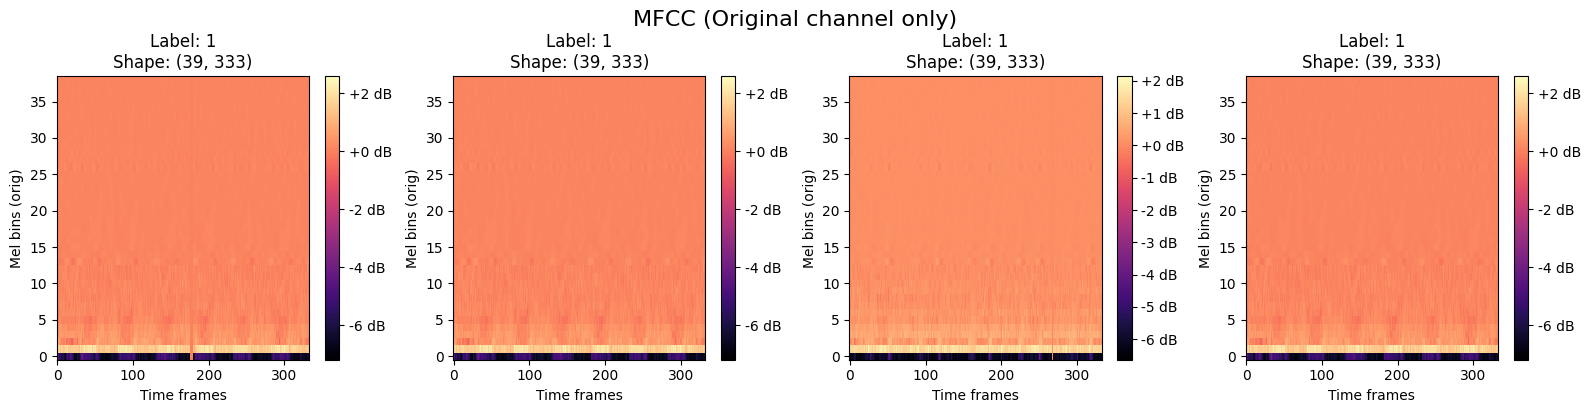

In [58]:
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
import h5py
from pathlib import Path

print("=== Debug DataLoader (FINAL FIXED VERSION) ===")
fea_path = str(DATASET_PATH/"mfcc_train.h5")

# Load label CSV
label_df = pd.read_csv(DATASET_PATH / 'label_train_augmented.csv')
print("Label CSV columns:", label_df.columns.tolist())

# Sửa filename thành stem
label_df['filename'] = label_df['filename'].apply(lambda x: Path(x).stem)

# Kiểm tra HDF5 keys
with h5py.File(fea_path, 'r') as f:
    print("First 10 HDF5 keys:", list(f.keys())[:10])

# Debug dataset
debug_dataset = HeartSoundDataSet(
    fea_path=fea_path,
    labels=label_df.head(8),
    duration=5,
    training=True,
    delta=True,   # Đang bật delta → 384 mel bins
    norm=True
)

debug_loader = DataLoader(debug_dataset, batch_size=4, shuffle=True, num_workers=0)

for data, target in debug_loader:
    print(f"Batch shape: {data.shape}")
    print(f"Targets: {target.numpy()}")
    print(f"Value range: {data.min().item():.3f} ~ {data.max().item():.3f}")

    # === PHẦN VISUALIZE ĐÃ FIX ===
    plt.figure(figsize=(16, 4))
    for i in range(data.shape[0]):
        plt.subplot(1, 4, i + 1)

        spectrogram = data[i].numpy()  # shape: (384, 333) nếu delta=True, hoặc (128, 333) nếu delta=False

        # Nếu dùng delta → tách ra để chỉ vẽ channel gốc (128 mel bins đầu tiên)
        if spectrogram.shape[0] == 384:  # 3 * 128
            img = spectrogram[:128, :]   # Chỉ lấy phần logmel gốc (channel 0)
        else:
            img = spectrogram            # Không delta → vẽ hết

        plt.imshow(img, aspect='auto', origin='lower', cmap='magma', interpolation='nearest')
        plt.title(f"Label: {target[i].item()}\nShape: {img.shape}")
        plt.xlabel("Time frames")
        plt.ylabel("Mel bins (orig)")
        plt.colorbar(format='%+2.0f dB')
        plt.tight_layout()

    plt.suptitle("MFCC (Original channel only)", fontsize=16, y=1.02)
    plt.show()
    break

# ConfigParser

In [59]:
# parse_config.py
import os
import logging
from pathlib import Path
from datetime import datetime
import argparse
import collections
import importlib.util

class ConfigParser:
    def __init__(self, config_dict, resume=None, modification=None, run_id=None):
        self._config = config_dict
        self.resume = resume

        # Apply CLI modifications
        if modification:
            for key_path, value in modification.items():
                keys = key_path.split(';')
                d = self._config
                for k in keys[:-1]:
                    d = d[k]
                d[keys[-1]] = value

        # Setup save and log directories
        save_dir = Path(self.config['trainer']['save_dir'])
        exper_name = self.config['name']
        if run_id is None:
            run_id = datetime.now().strftime(r'%m%d_%H%M%S')
        self._save_dir = save_dir / 'models' / exper_name / run_id
        self._log_dir = save_dir / 'log' / exper_name / run_id

        self.save_dir.mkdir(parents=True, exist_ok=True)
        self.log_dir.mkdir(parents=True, exist_ok=True)

        # Optional: setup logging
        # setup_logging(self.log_dir)

    @classmethod
    def from_args(cls, parser, options=None):
        """
        parser: argparse.ArgumentParser đã được add_argument xong
        options: list các CustomArgs để override
        """
        if options is None:
            options = []

        # Parse arguments (an toàn cho cả terminal và notebook)
        args = parser.parse_args()

        # Xử lý device
        if args.device is not None:
            os.environ["CUDA_VISIBLE_DEVICES"] = args.device

        # Xử lý resume
        if args.resume is not None:
            resume = Path(args.resume)
            cfg_fname = resume.parent / 'config.py'  # hoặc .json nếu bạn dùng cả 2
        else:
            resume = None
            assert args.config is not None, "Phải chỉ định -c config.py"
            cfg_fname = Path(args.config)

        # Đọc config từ file .py
        if not cfg_fname.exists():
            raise FileNotFoundError(f"Không tìm thấy config file: {cfg_fname}")

        if cfg_fname.suffix == '.py':
            spec = importlib.util.spec_from_file_location("config_module", cfg_fname)
            config_module = importlib.util.module_from_spec(spec)
            spec.loader.exec_module(config_module)
            if not hasattr(config_module, 'config'):
                raise ValueError(f"File {cfg_fname} phải định nghĩa biến 'config'")
            config_dict = config_module.config
        else:
            raise ValueError("Chỉ hỗ trợ file config .py")

        # Parse custom CLI overrides
        CustomArgs = collections.namedtuple('CustomArgs', 'flags type target')
        modification = {}
        for opt in options:
            for flag in opt.flags:
                arg_name = flag.lstrip('-').replace('-', '_')
                if hasattr(args, arg_name) and getattr(args, arg_name) is not None:
                    modification[opt.target] = opt.type(getattr(args, arg_name))

        return cls(config_dict, resume, modification)

    def init_obj(self, name, module, *args, **kwargs):
        module_name = self[name]['type']
        module_args = dict(self[name]['args'])
        module_args.update(kwargs)
        if isinstance(module, dict):
            obj_class = module[module_name]
        else:
            obj_class = getattr(module, module_name)

        return obj_class(*args, **module_args)

    def init_ftn(self, name, module, *args, **kwargs):
        from functools import partial
        module_name = self[name]['type']
        module_args = dict(self[name]['args'])
        module_args.update(kwargs)
        if isinstance(module, dict):
            obj_class = module[module_name]
        else:
            obj_class = getattr(module, module_name)

        return obj_class(*args, **module_args)

    def __getitem__(self, name):
        return self.config[name]

    def get_logger(self, name, verbosity=2):
        logger = logging.getLogger(name)
        logger.setLevel({0: logging.WARNING, 1: logging.INFO, 2: logging.DEBUG}[verbosity])
        return logger

    @property
    def config(self):
        return self._config

    @property
    def save_dir(self):
        return self._save_dir

    @property
    def log_dir(self):
        return self._log_dir

# Logging

In [60]:
def mixup_data(x, y, alpha=0.2):
    """Mixup augmentation"""
    lam = np.random.beta(alpha, alpha)
    batch_size = x.size(0)
    index = torch.randperm(batch_size).to(x.device)

    mixed_x = lam * x + (1 - lam) * x[index]
    y_a, y_b = y, y[index]
    return mixed_x, y_a, y_b, lam

def mixup_criterion(criterion, pred, y_a, y_b, lam):
    return lam * criterion(pred, y_a) + (1 - lam) * criterion(pred, y_b)

In [61]:
import importlib
from datetime import datetime


class TensorboardWriter():
    def __init__(self, log_dir, logger, enabled):
        self.writer = None
        self.selected_module = ""

        if enabled:
            log_dir = str(log_dir)

            # Retrieve vizualization writer.
            succeeded = False
            for module in ["torch.utils.tensorboard", "tensorboardX"]:
                try:
                    self.writer = importlib.import_module(module).SummaryWriter(log_dir)
                    succeeded = True
                    break
                except ImportError:
                    succeeded = False
                self.selected_module = module

            if not succeeded:
                message = "Warning: visualization (Tensorboard) is configured to use, but currently not installed on " \
                    "this machine. Please install TensorboardX with 'pip install tensorboardx', upgrade PyTorch to " \
                    "version >= 1.1 to use 'torch.utils.tensorboard' or turn off the option in the 'config.json' file."
                logger.warning(message)

        self.step = 0
        self.mode = ''

        self.tb_writer_ftns = {
            'add_scalar', 'add_scalars', 'add_image', 'add_images', 'add_audio',
            'add_text', 'add_histogram', 'add_pr_curve', 'add_embedding'
        }
        self.tag_mode_exceptions = {'add_histogram', 'add_embedding'}
        self.timer = datetime.now()

    def set_step(self, step, mode='train'):
        self.mode = mode
        self.step = step
        if step == 0:
            self.timer = datetime.now()
        else:
            duration = datetime.now() - self.timer
            self.add_scalar('steps_per_sec', 1 / duration.total_seconds())
            self.timer = datetime.now()

    def __getattr__(self, name):
        """
        If visualization is configured to use:
            return add_data() methods of tensorboard with additional information (step, tag) added.
        Otherwise:
            return a blank function handle that does nothing
        """
        if name in self.tb_writer_ftns:
            add_data = getattr(self.writer, name, None)

            def wrapper(tag, data, *args, **kwargs):
                if add_data is not None:
                    # add mode(train/valid) tag
                    if name not in self.tag_mode_exceptions:
                        tag = '{}/{}'.format(tag, self.mode)
                    add_data(tag, data, self.step, *args, **kwargs)
            return wrapper
        else:
            # default action for returning methods defined in this class, set_step() for instance.
            try:
                attr = object.__getattr__(name)
            except AttributeError:
                raise AttributeError("type object '{}' has no attribute '{}'".format(self.selected_module, name))
            return attr

#Loss

In [62]:
class FocalLoss(nn.Module):
    def __init__(self, alpha=0.25, gamma=1.5):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, inputs, targets):
        weight = torch.tensor(
            [self.alpha, 1 - self.alpha], device=inputs.device
        ).float()   # [w_normal, w_abnormal]
        ce_loss = F.cross_entropy(inputs, targets, weight=weight, reduction='none')
        pt = torch.exp(-ce_loss)
        focal_loss = (1 - pt) ** self.gamma * ce_loss
        return focal_loss.mean()

In [63]:
class CBFocalLoss(nn.Module):
    def __init__(self, samples_per_class, beta=0.9999, gamma=2.0):
        super().__init__()
        effective_num = 1.0 - np.power(beta, samples_per_class)
        weights = (1.0 - beta) / np.array(effective_num)
        self.weights = weights / np.sum(weights) * len(samples_per_class)
        self.gamma = gamma

    def forward(self, inputs, targets):
        weights = torch.tensor(self.weights, device=inputs.device).float()
        ce_loss = F.cross_entropy(inputs, targets, weight=weights, reduction='none')
        pt = torch.exp(-ce_loss)
        focal_loss = (1-pt)**self.gamma * ce_loss
        return focal_loss.mean()

# Sử dụng:
# samples_per_class = [số_mẫu_abnormal, số_mẫu_normal]

In [64]:
class WeightedCELoss(nn.Module):
    """
    Weighted Cross Entropy Loss
    """
    def __init__(self, weights):
        super().__init__()
        self.register_buffer(
            "weights", torch.tensor(weights, dtype=torch.float)
        )

    def forward(self, logits, target):
        return F.cross_entropy(
            logits,
            target,
            weight=self.weights
        )


In [65]:
class CostSensitiveLoss(nn.Module):
    """
    Cost-sensitive Cross Entropy
    FN (abnormal → normal) bị phạt nặng hơn FP
    """
    def __init__(self, fn_cost=2.5, fp_cost=1.0):
        super().__init__()
        self.fn_cost = fn_cost
        self.fp_cost = fp_cost

    def forward(self, logits, target):
        weights = torch.tensor(
            [self.fp_cost, self.fn_cost],
            device=logits.device
        )

        return F.cross_entropy(
            logits,
            target,
            weight=weights
        )

In [66]:
class AsymmetricFocalLoss(nn.Module):
    """
    Focal Loss với gamma khác nhau cho positive/negative.
    gamma_neg cao hơn → phạt nặng hơn khi predict FP → tăng Precision → tăng F1.
    """
    def __init__(self, gamma_pos=1.0, gamma_neg=1.0, label_smoothing=0.05):
        super().__init__()
        self.gamma_pos = gamma_pos   # Nhẹ tay với Abnormal (giữ Sensitivity)
        self.gamma_neg = gamma_neg   # Mạnh tay với Normal bị predict sai (giảm FP)
        self.ls = label_smoothing

    def forward(self, logits, targets):
        ce = F.cross_entropy(logits, targets, label_smoothing=self.ls, reduction='none')
        probs = torch.softmax(logits, dim=1)
        pt = probs[torch.arange(len(targets)), targets]
        gamma = torch.where(targets == 1,
                            torch.full_like(pt, self.gamma_pos),
                            torch.full_like(pt, self.gamma_neg))
        loss = ((1 - pt) ** gamma) * ce
        return loss.mean()

In [67]:
class CombinedLoss(nn.Module):
    def __init__(self, alpha=0.7, gamma=2.5, label_smoothing=0.1, focal_weight=0.7):
        self.focal_loss = ImprovedFocalLoss(alpha, gamma, label_smoothing)
        self.ce_loss = nn.CrossEntropyLoss(label_smoothing=label_smoothing)

In [68]:
import torch.nn.functional as F


def nll_loss(output, target):
    return F.nll_loss(output, target)

def ce_loss(output, target):
    return F.cross_entropy(output, target)

def focal_loss(output, target, alpha=0.75, gamma=2.0):
    return FocalLoss(alpha=alpha, gamma=gamma)(output, target)

# Dùng khi tỷ lệ abnormal ≪ normal.
def weighted_ce_loss(output, target, weights):
    return WeightedCELoss(weights)(output, target)

# Đặc biệt phù hợp bài toán y sinh, nơi bỏ sót bệnh (FN) nguy hiểm hơn FP.
def cost_sensitive_loss(output, target, fn_cost=2.5, fp_cost=1.0):
    return CostSensitiveLoss(fn_cost, fp_cost)(output, target)

LOSS_REGISTRY = {
    "ce_loss": lambda: nn.CrossEntropyLoss(),
    "focal_loss": lambda: FocalLoss(alpha=0.75, gamma=2.0),
    "cost_sensitive_loss": lambda: CostSensitiveLoss(fn_cost=2.5, fp_cost=1.0),
    "weighted_ce_loss": lambda weights: WeightedCELoss(weights),
}

# Metric

In [69]:
import torch


def accuracy(output, target):
    with torch.no_grad():
        pred = torch.argmax(output, dim=1)
        assert pred.shape[0] == len(target)
        correct = 0
        correct += torch.sum(pred == target).item()
    return correct / len(target)

import torch

def sensitivity(output, target, positive_class=1, eps=1e-8):
    with torch.no_grad():
        pred = torch.argmax(output, dim=1)
        tp = torch.sum((pred == positive_class) & (target == positive_class)).item()
        fn = torch.sum((pred != positive_class) & (target == positive_class)).item()
    return tp / (tp + fn + eps)


def f1_score(output, target, positive_class=1, eps=1e-8):
    with torch.no_grad():
        pred = torch.argmax(output, dim=1)

        tp = torch.sum((pred == positive_class) & (target == positive_class)).item()
        fp = torch.sum((pred == positive_class) & (target != positive_class)).item()
        fn = torch.sum((pred != positive_class) & (target == positive_class)).item()

        precision = tp / (tp + fp + eps)
        recall    = tp / (tp + fn + eps)

        f1 = 2 * precision * recall / (precision + recall + eps)

    return f1

In [70]:
from torch.optim.lr_scheduler import CosineAnnealingLR

# Warmup scheduler
class WarmupCosineScheduler:
    """
    Warmup tuyến tính + Cosine decay một chiều (KHÔNG restart).
    Thêm get_last_lr() để tương thích với Trainer.
    """
    def __init__(self, optimizer, warmup_epochs=5, total_epochs=120, lr_min=1e-6):
        self.optimizer      = optimizer
        self.warmup_epochs  = warmup_epochs
        self.total_epochs   = total_epochs
        self.lr_min         = lr_min
        self.base_lr        = optimizer.param_groups[0]['lr']
        self._current_lr    = self.base_lr

    def step(self, epoch):
        if epoch < self.warmup_epochs:
            # Tuyến tính từ lr_min → base_lr
            lr = self.lr_min + (self.base_lr - self.lr_min) * (epoch + 1) / self.warmup_epochs
        else:
            # Cosine một chiều: base_lr → lr_min (KHÔNG restart)
            progress = (epoch - self.warmup_epochs) / max(
                self.total_epochs - self.warmup_epochs, 1
            )
            progress = min(progress, 1.0)           # clamp tránh vượt 1.0
            lr = self.lr_min + (self.base_lr - self.lr_min) * 0.5 * (
                1.0 + np.cos(np.pi * progress)
            )
        self._current_lr = lr
        for pg in self.optimizer.param_groups:
            pg['lr'] = lr
        return lr

    def get_last_lr(self):
        return [self._current_lr]


In [71]:
class EarlyStopping:
    def __init__(self, patience=7, min_delta=0.001):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_score = None

    def __call__(self, val_loss):
        if self.best_score is None:
            self.best_score = val_loss
        elif val_loss > self.best_score - self.min_delta:
            self.counter += 1
            if self.counter >= self.patience:
                return True
        else:
            self.best_score = val_loss
            self.counter = 0
        return False

# Model


In [72]:
import torch.nn as nn
import numpy as np
from abc import abstractmethod


class BaseModel(nn.Module):
    """
    Base class for all models
    """
    @abstractmethod
    def forward(self, *inputs):
        """
        Forward pass logic

        :return: Model output
        """
        raise NotImplementedError

    def __str__(self):
        """
        Model prints with number of trainable parameters
        """
        model_parameters = filter(lambda p: p.requires_grad, self.parameters())
        params = sum([np.prod(p.size()) for p in model_parameters])
        return super().__str__() + '\nTrainable parameters: {}'.format(params)

In [73]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# functions of initializing layers
def init_layer(layer):
    """Initialize a Linear or Convolutional layer."""
    nn.init.xavier_uniform_(layer.weight)

    if hasattr(layer, 'bias'):
        if layer.bias is not None:
            layer.bias.data.fill_(0.)

def init_bn(bn):
    """Initialize a Batchnorm layer."""
    bn.bias.data.fill_(0.)
    bn.weight.data.fill_(1.)

def init_rnn(rnn):
    """init_rnn
    Initialized RNN weights, independent of type GRU/LSTM/RNN
    :param rnn: the rnn model
    """
    for name, param in rnn.named_parameters():
        if 'bias' in name:
            nn.init.constant_(param, 0.0)
        elif 'weight' in name:
            nn.init.xavier_uniform_(param)

def reset_parameters(model):
    for module in model.modules():
        if isinstance(module, nn.Conv2d):
            init_layer(module)
        elif isinstance(module, nn.Linear):
            init_layer(module)
        elif isinstance(module, nn.BatchNorm2d):
            init_bn(module)
        elif isinstance(module, nn.LSTM):
            init_rnn(module)


## Simple CNN Block

## Lightweight CNN Architecture

In [74]:
class DSConvBlock(nn.Module):
    """Depthwise Separable Conv — đơn giản, dễ quantize INT8."""
    def __init__(self, in_ch, out_ch, stride=1):
        super().__init__()
        self.dw  = nn.Conv2d(in_ch, in_ch, 3, stride, 1, groups=in_ch, bias=False)
        self.pw  = nn.Conv2d(in_ch, out_ch, 1, bias=False)
        self.bn  = nn.BatchNorm2d(out_ch)
        self.act = nn.ReLU6(inplace=True)

    def forward(self, x):
        return self.act(self.bn(self.pw(self.dw(x))))


class LiteSEBlock(nn.Module):
    """SE Block thu gọn: channels=64, reduction=8 → chỉ 1,024 params."""
    def __init__(self, channels, reduction=8):
        super().__init__()
        mid = max(channels // reduction, 4)
        self.gap = nn.AdaptiveAvgPool2d(1)
        self.fc  = nn.Sequential(
            nn.Linear(channels, mid),
            nn.ReLU(inplace=True),
            nn.Linear(mid, channels),
            nn.Sigmoid()
        )

    def forward(self, x):
        B, C, _, _ = x.shape
        s = self.gap(x).view(B, C)
        return x * self.fc(s).view(B, C, 1, 1)

In [75]:
class LightweightHeartSoundCNN(nn.Module):
    def __init__(self, num_classes=2, in_channel=1, dropout=0.5):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv2d(in_channel, 24, kernel_size=(5, 5), stride=1, padding=2, bias=False),
            nn.BatchNorm2d(24),
            nn.ReLU6(inplace=True),
            nn.Dropout2d(0.1)
        )
        self.stage1 = nn.Sequential(
            DSConvBlock(24, 32),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        self.stage2 = nn.Sequential(
            DSConvBlock(32, 48),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        self.stage3   = DSConvBlock(48, 48)
        self.se       = LiteSEBlock(48, reduction=4)
        self.gap      = nn.AdaptiveAvgPool2d(1)

        # Bổ sung các lớp còn thiếu để forward không lỗi
        self.bn_head  = nn.BatchNorm1d(48)
        self.dropout_layer = nn.Dropout(dropout)

        self.classifier = nn.Sequential(
            nn.Linear(48, 16),
            nn.ReLU6(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(16, num_classes)
        )

        # Gọi hàm khởi tạo trọng số
        self._init_weights()

    # PHẢI THỤT LỀ VÀO TRONG CLASS
    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, nn.BatchNorm2d) or isinstance(m, nn.BatchNorm1d):
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, x):
        # x: (B, 39, 333)
        if x.dim() == 3:
            x = x.unsqueeze(1)          # (B, 1, 39, 333)

        x = self.stem(x)
        x = self.stage1(x)
        x = self.stage2(x)
        x = self.stage3(x)
        x = self.se(x)
        x = self.gap(x).flatten(1)      # (B, 48)

        x = self.bn_head(x)
        x = self.dropout_layer(x)
        return self.classifier(x)

    def __str__(self):
        params = sum(p.numel() for p in self.parameters() if p.requires_grad)
        return super().__str__() + f'\nTrainable parameters: {params:,}'

## Deeper CNN model, VGG like structure

## RNN - BiLTSM

## CRNN

# Config

## CNN

## Lightweight CNN Architecture

In [76]:
from pathlib import Path

config_light_cnn = {
    "name": "Physionet_lightweight_cnn",
    "n_gpu": 1,

    # --------------------------------------------------------
    # Model architecture
    # --------------------------------------------------------
    "arch": {
        "type": "LightweightHeartSoundCNN",
        "args": {
            "num_classes": 2,
            "in_channel": 1, #Declare channel
            "dropout": 0.6
        }
    },

    # --------------------------------------------------------
    # Data loader configuration
    # --------------------------------------------------------
    "data_loader": {
        "type": "HeartSoundDataLoader",
        "full_label_csv": str(DATASET_PATH/ "label_train_augmented.csv"),
        "args": {
            # Extracted Log-Mel features directory
            "fea_path": str(DATASET_PATH/"mfcc_train.h5"),
            "duration": 5,
            "batch_size": 64,
            "delta": False, #Remove delta
            "norm": True,
            "shuffle": True,
            "validation_split": 0.0,
            "num_workers": 2,
            "label_df": pd.read_csv(str(DATASET_PATH/ "label_train_augmented.csv"))
        }
    },

    # --------------------------------------------------------
    # Optimizer
    # --------------------------------------------------------
    "optimizer": {
        "type": "AdamW",
        "args": {
            "lr": 2e-4, #2e-4
            "weight_decay": 1e-3, #0.0
            "amsgrad": True
        }
    },

    # --------------------------------------------------------
    # Loss function and metrics
    # --------------------------------------------------------
    "loss": "combined_loss",
    "metrics": [
    ],

    # --------------------------------------------------------
    # Learning rate scheduler
    # --------------------------------------------------------
    "lr_scheduler": {
        "type": "WarmupCosine",
        "args": {
            #"mode": "max",
            #"factor": 0.5,
            #"patience": 10, # Tránh giảm LR quá sớm khi model chưa kịp học
            #"min_lr": 5e-7
            "warmup_epochs": 5,
            "total_epochs": 100,
            "lr_min": 5e-7
        }
    },

    # --------------------------------------------------------
    # Trainer configuration
    # --------------------------------------------------------
    "trainer": {
        "epochs": 200,
        "save_dir": str(PROJECT_PATH / "saved"/"lightweight_cnn"),
        "save_period": 1,
        "verbosity": 2,
        "monitor": "max val_MAcc",
        "early_stop": 15,
        "tensorboard": True,
        "use_mixup": True,
        "mixup_alpha": 0.1,
        "gradient_clip": 1.0
    }
}

## CRNN

## LTSM

## VGG

# Training

In [77]:
def prepare_device(n_gpu_use):
    """
    setup GPU device if available. get gpu device indices which are used for DataParallel
    """
    n_gpu = torch.cuda.device_count()
    if n_gpu_use > 0 and n_gpu == 0:
        print("Warning: There\'s no GPU available on this machine,"
              "training will be performed on CPU.")
        n_gpu_use = 0
    if n_gpu_use > n_gpu:
        print(f"Warning: The number of GPU\'s configured to use is {n_gpu_use}, but only {n_gpu} are "
              "available on this machine.")
        n_gpu_use = n_gpu
    device = torch.device('cuda:0' if n_gpu_use > 0 else 'cpu')
    list_ids = list(range(n_gpu_use))
    return device, list_ids

In [78]:
class MetricTracker:
    def __init__(self, *keys, writer=None):
        self.writer = writer
        self._data = pd.DataFrame(index=keys, columns=['total', 'counts', 'average'])
        self.reset()

    def reset(self):
        for col in self._data.columns:
            self._data[col].values[:] = 0

    def update(self, key, value, n=1):
        if self.writer is not None:
            self.writer.add_scalar(key, value)
        df = self._data

        df.loc[key, "total"] += value * n
        df.loc[key, "counts"] += n
        df.loc[key, "average"] = df.loc[key, "total"] / df.loc[key, "counts"]


    def avg(self, key):
        return self._data.average[key]

    def result(self):
        return dict(self._data.average)

In [79]:
def setup_logging(save_dir, log_config='logger/logger_config.json', default_level=logging.INFO):
    """
    Setup logging configuration
    """
    log_config = Path(log_config)
    if log_config.is_file():
        config = read_json(log_config)
        # modify logging paths based on run config
        for _, handler in config['handlers'].items():
            if 'filename' in handler:
                handler['filename'] = str(save_dir / handler['filename'])

        logging.config.dictConfig(config)
    else:
        print("Warning: logging configuration file is not found in {}.".format(log_config))
        logging.basicConfig(level=default_level)
import importlib
from datetime import datetime


class TensorboardWriter():
    def __init__(self, log_dir, logger, enabled):
        self.writer = None
        self.selected_module = ""

        if enabled:
            log_dir = str(log_dir)

            # Retrieve vizualization writer.
            succeeded = False
            for module in ["torch.utils.tensorboard", "tensorboardX"]:
                try:
                    self.writer = importlib.import_module(module).SummaryWriter(log_dir)
                    succeeded = True
                    break
                except ImportError:
                    succeeded = False
                self.selected_module = module

            if not succeeded:
                message = "Warning: visualization (Tensorboard) is configured to use, but currently not installed on " \
                    "this machine. Please install TensorboardX with 'pip install tensorboardx', upgrade PyTorch to " \
                    "version >= 1.1 to use 'torch.utils.tensorboard' or turn off the option in the 'config.json' file."
                logger.warning(message)

        self.step = 0
        self.mode = ''

        self.tb_writer_ftns = {
            'add_scalar', 'add_scalars', 'add_image', 'add_images', 'add_audio',
            'add_text', 'add_histogram', 'add_pr_curve', 'add_embedding'
        }
        self.tag_mode_exceptions = {'add_histogram', 'add_embedding'}
        self.timer = datetime.now()

    def set_step(self, step, mode='train'):
        self.mode = mode
        self.step = step
        if step == 0:
            self.timer = datetime.now()
        else:
            duration = datetime.now() - self.timer
            self.add_scalar('steps_per_sec', 1 / duration.total_seconds())
            self.timer = datetime.now()

    def __getattr__(self, name):
        """
        If visualization is configured to use:
            return add_data() methods of tensorboard with additional information (step, tag) added.
        Otherwise:
            return a blank function handle that does nothing
        """
        if name in self.tb_writer_ftns:
            add_data = getattr(self.writer, name, None)

            def wrapper(tag, data, *args, **kwargs):
                if add_data is not None:
                    # add mode(train/valid) tag
                    if name not in self.tag_mode_exceptions:
                        tag = '{}/{}'.format(tag, self.mode)
                    add_data(tag, data, self.step, *args, **kwargs)
            return wrapper
        else:
            # default action for returning methods defined in this class, set_step() for instance.
            try:
                attr = object.__getattr__(name)
            except AttributeError:
                raise AttributeError("type object '{}' has no attribute '{}'".format(self.selected_module, name))
            return attr

In [80]:
import torch
from abc import abstractmethod
from numpy import inf

def safe_append(lst, value):
    lst.append(value if value is not None else np.nan)

class BaseTrainer:
    """
    Base class for all trainers
    """
    def __init__(self, model, criterion, metric_ftns, optimizer, config):
        self.config = config
        self.logger = config.get_logger('trainer', config['trainer']['verbosity'])

        self.model = model
        self.criterion = criterion
        self.metric_ftns = metric_ftns
        self.optimizer = optimizer

        cfg_trainer = config['trainer']
        self.epochs = cfg_trainer['epochs']
        self.save_period = cfg_trainer['save_period']
        self.monitor = cfg_trainer.get('monitor', 'off')

        # configuration to monitor model performance and save best
        if self.monitor == 'off':
            self.mnt_mode = 'off'
            self.mnt_best = 0
        else:
            self.mnt_mode, self.mnt_metric = self.monitor.split()
            assert self.mnt_mode in ['min', 'max']

            self.mnt_best = inf if self.mnt_mode == 'min' else -inf
            self.early_stop = cfg_trainer.get('early_stop', inf)
            if self.early_stop <= 0:
                self.early_stop = inf

        self.start_epoch = 1

        self.checkpoint_dir = config.save_dir

        self.history = {
            "epoch": [],
            "train_loss": [],
            "train_accuracy": [],
            "val_loss": [],
            "val_accuracy": [],
            "val_F1_score": [],
            "val_sensitivity": [],
            "val_specificity": [],
            "val_MAcc": []
        }


        self.history_path = Path(self.checkpoint_dir) / "metrics.csv"

        # setup visualization writer instance
        self.writer = TensorboardWriter(config.log_dir, self.logger, cfg_trainer['tensorboard'])

        if config.resume is not None:
            self._resume_checkpoint(config.resume)

    @abstractmethod
    def _train_epoch(self, epoch):
        """
        Training logic for an epoch

        :param epoch: Current epoch number
        """
        raise NotImplementedError

    def train(self):
        """
        Full training logic
        """
        not_improved_count = 0
        for epoch in range(self.start_epoch, self.epochs + 1):
            result = self._train_epoch(epoch)

            # save logged informations into log dict
            log = {'epoch': epoch}
            log.update(result)

            # ===== GHI METRICS SAU MỖI EPOCH =====
            safe_append(self.history["epoch"], epoch)
            safe_append(self.history["train_loss"], log.get("loss"))
            safe_append(self.history["train_accuracy"], log.get("accuracy"))

            safe_append(self.history["val_loss"], log.get("val_loss"))
            safe_append(self.history["val_accuracy"], log.get("val_accuracy"))
            safe_append(self.history["val_F1_score"], log.get("val_F1_score"))
            safe_append(self.history["val_sensitivity"], log.get("val_sensitivity"))
            safe_append(self.history["val_specificity"], log.get("val_specificity"))
            safe_append(self.history["val_MAcc"], log.get("val_MAcc"))



            pd.DataFrame(self.history).to_csv(self.history_path, index=False)

            # print logged informations to the screen
            for key, value in log.items():
                self.logger.info('    {:15s}: {}'.format(str(key), value))

            # evaluate model performance according to configured metric, save best checkpoint as model_best
            best = False
            if self.mnt_mode != 'off':
                try:
                    # check whether model performance improved or not, according to specified metric(mnt_metric)
                    improved = (self.mnt_mode == 'min' and log[self.mnt_metric] <= self.mnt_best) or \
                               (self.mnt_mode == 'max' and log[self.mnt_metric] >= self.mnt_best)
                except KeyError:
                    self.logger.warning("Warning: Metric '{}' is not found. "
                                        "Model performance monitoring is disabled.".format(self.mnt_metric))
                    self.mnt_mode = 'off'
                    improved = False

                if improved:
                    self.mnt_best = log[self.mnt_metric]
                    not_improved_count = 0
                    best = True
                else:
                    not_improved_count += 1

                if not_improved_count > self.early_stop:
                    self.logger.info("Validation performance didn\'t improve for {} epochs. "
                                     "Training stops.".format(self.early_stop))
                    break

            if best:
                self._save_best_model(epoch)

    def _save_checkpoint(self, epoch, save_best=False):
        """
        Saving checkpoints

        :param epoch: current epoch number
        :param log: logging information of the epoch
        :param save_best: if True, rename the saved checkpoint to 'model_best.pth'
        """
        arch = type(self.model).__name__
        state = {
            'arch': arch,
            'epoch': epoch,
            'state_dict': self.model.state_dict(),
            'optimizer': self.optimizer.state_dict(),
            'monitor_best': self.mnt_best,
            'config': self.config
        }
        filename = str(self.checkpoint_dir / 'checkpoint-epoch{}.pth'.format(epoch))
        torch.save(state, filename)
        self.logger.info("Saving checkpoint: {} ...".format(filename))
        if save_best:
            best_path = str(self.checkpoint_dir / 'model_best.pth')
            torch.save(state, best_path)
            self.logger.info("Saving current best: model_best.pth ...")

    def _resume_checkpoint(self, resume_path):
        """
        Resume from saved checkpoints

        :param resume_path: Checkpoint path to be resumed
        """
        resume_path = str(resume_path)
        self.logger.info("Loading checkpoint: {} ...".format(resume_path))
        checkpoint = torch.load(resume_path)
        self.start_epoch = checkpoint['epoch'] + 1
        self.mnt_best = checkpoint['monitor_best']

        # load architecture params from checkpoint.
        if checkpoint['config']['arch'] != self.config['arch']:
            self.logger.warning("Warning: Architecture configuration given in config file is different from that of "
                                "checkpoint. This may yield an exception while state_dict is being loaded.")
        self.model.load_state_dict(checkpoint['state_dict'])

        # load optimizer state from checkpoint only when optimizer type is not changed.
        if checkpoint['config']['optimizer']['type'] != self.config['optimizer']['type']:
            self.logger.warning("Warning: Optimizer type given in config file is different from that of checkpoint. "
                                "Optimizer parameters not being resumed.")
        else:
            self.optimizer.load_state_dict(checkpoint['optimizer'])

        self.logger.info("Checkpoint loaded. Resume training from epoch {}".format(self.start_epoch))

    def _save_best_model(self, epoch):
      """
      Save only the best model according to monitoring metric
      """
      arch = type(self.model).__name__
      state = {
          'arch': arch,
          'epoch': epoch,
          'state_dict': self.model.state_dict(),
          'optimizer': self.optimizer.state_dict(),
          'monitor_best': self.mnt_best,
          'config': self.config
      }

      best_path = self.checkpoint_dir / 'model_best.pth'
      torch.save(state, best_path)

      self.logger.info(
          f"Saving new best model at epoch {epoch}: model_best.pth"
      )


In [81]:
from itertools import repeat

def inf_loop(data_loader):
    ''' wrapper function for endless data loader. '''
    for loader in repeat(data_loader):
        yield from loader

In [82]:
class Trainer(BaseTrainer):
    """
    Trainer class
    """
    def __init__(self, model, criterion, metric_ftns, optimizer, config, device,
                 data_loader, valid_data_loader=None, lr_scheduler=None, len_epoch=None):
        super().__init__(model, criterion, metric_ftns, optimizer, config)
        self.config = config
        self.device = device
        self.data_loader = data_loader
        if len_epoch is None:
            # epoch-based training
            self.len_epoch = len(self.data_loader)
        else:
            # iteration-based training
            self.data_loader = inf_loop(data_loader)
            self.len_epoch = len_epoch
        self.valid_data_loader = valid_data_loader
        self.do_validation = self.valid_data_loader is not None
        self.lr_scheduler = lr_scheduler

        cfg_trainer = config['trainer']
        self.use_mixup = cfg_trainer.get("use_mixup", False)
        self.mixup_alpha = cfg_trainer.get("mixup_alpha", 0.2)
        self.gradient_clip = cfg_trainer.get("gradient_clip", 0.0)

        self.log_step = int(np.sqrt(data_loader.batch_size))

        self.train_metrics = MetricTracker('loss', *[m.__name__ for m in self.metric_ftns], writer=self.writer)
        self.valid_metrics = MetricTracker('loss',*[m.__name__ for m in self.metric_ftns],
                                           'sensitivity', 'specificity', 'MAcc', 'F1_score',
                                           writer = self.writer)


    def _train_epoch(self, epoch):
        """
        Training logic for an epoch

        :param epoch: Integer, current training epoch.
        :return: A log that contains average loss and metric in this epoch.
        """
        self.model.train()
        self.train_metrics.reset()
        for batch_idx, (data, target) in enumerate(self.data_loader):
            data, target = data.to(self.device), target.to(self.device)

            self.optimizer.zero_grad()

            if self.use_mixup and np.random.rand() > 0.5:
                data, targets_a, targets_b, lam = mixup_data(data, target, alpha=self.mixup_alpha)
                output = self.model(data)
                loss = mixup_criterion(self.criterion, output, targets_a, targets_b, lam)
            else:
                output = self.model(data)
                loss = self.criterion(output, target)


            if not torch.isfinite(loss):
                print(f"NaN/Inf loss tại epoch {epoch}, batch {batch_idx} — skipping")
                self.optimizer.zero_grad()
                continue

            loss.backward()
            if self.gradient_clip > 0:
                torch.nn.utils.clip_grad_norm_(self.model.parameters(), self.gradient_clip)


            total_norm = 0
            for p in self.model.parameters():
                if p.grad is not None:
                    total_norm += p.grad.data.norm(2).item() ** 2
            total_norm = total_norm ** 0.5
            if not np.isfinite(total_norm):
                print(f"NaN gradient tại epoch {epoch}, batch {batch_idx} — skipping")
                self.optimizer.zero_grad()
                continue


            self.optimizer.step()
            if hasattr(self, 'ema'):
                self.ema.update()


            self.writer.set_step((epoch - 1) * self.len_epoch + batch_idx)
            self.train_metrics.update('loss', loss.item())
            for met in self.metric_ftns:
                self.train_metrics.update(met.__name__, met(output, target))

            if batch_idx % self.log_step == 0:
                self.logger.debug('Train Epoch: {} {} Loss: {:.6f}'.format(
                    epoch,
                    self._progress(batch_idx),
                    loss.item()))
                #self.writer.add_image('input', make_grid(data.cpu(), nrow=8, normalize=True))

            if batch_idx == self.len_epoch:
                break
        log = self.train_metrics.result()

        if self.do_validation:
            val_log = self._valid_epoch(epoch)
            log.update(**{'val_'+k : v for k, v in val_log.items()})

        #if self.lr_scheduler is not None:
            #self.lr_scheduler.step()

        if self.lr_scheduler is not None:
            if isinstance(self.lr_scheduler, WarmupCosineScheduler):
                self.lr_scheduler.step(epoch - 1)   # epoch 1-based → 0-based
            elif isinstance(self.lr_scheduler, torch.optim.lr_scheduler.ReduceLROnPlateau):
                self.lr_scheduler.step(val_log.get('MAcc', val_log['loss']))
            else:
                self.lr_scheduler.step()
        return log

    def _valid_epoch(self, epoch):
        """
        Validate after training an epoch

        :param epoch: Integer, current training epoch.
        :return: A log that contains information about validation
        """
        self.model.eval()
        self.valid_metrics.reset()
        val_pred_pos = 0
        val_pred_neg = 0
        val_condition_pos = 0
        val_condition_neg = 0
        val_TP = 0
        val_TN = 0
        val_FP = 0   # ← THÊM DÒNG NÀY
        val_FN = 0   # ← THÊM DÒNG NÀY
        val_correct = 0
        val_total = 0
        use_ema = hasattr(self, 'ema')
        if use_ema:
            self.ema.apply_shadow()
        with torch.no_grad():
            for batch_idx, (data, target) in enumerate(self.valid_data_loader):
                data, target = data.to(self.device), target.to(self.device)
                output = self.model(data.float())
                loss = self.criterion(output, target)

                #_,indices = torch.max(output, 1)

                threshold = 0.65  # Bạn có thể thử 0.7, 0.8 hoặc 0.85
                probs = torch.softmax(output, dim=1)
                # Lấy xác suất của lớp Abnormal (lớp 1)
                abnormal_probs = probs[:, 1]
                # Nếu xác suất > threshold thì là 1, ngược lại là 0
                indices = (abnormal_probs >= threshold).long()

                val_TP += ((indices == 1) & (target == 1)).sum().item()
                val_TN += ((indices == 0) & (target == 0)).sum().item()
                val_FP += ((indices == 1) & (target == 0)).sum().item()
                val_FN += ((indices == 0) & (target == 1)).sum().item()

                val_correct += (indices == target).sum().item()
                val_total   += target.size(0)

                self.writer.set_step((epoch - 1) * len(self.valid_data_loader) + batch_idx, 'valid')
                self.valid_metrics.update('loss', loss.item())
                for met in self.metric_ftns:
                    self.valid_metrics.update(met.__name__, met(output, target))
                #self.writer.add_image('input', make_grid(data.cpu(), nrow=8, normalize=True))

        eps = 1e-8
        sensitivity = val_TP / (val_TP + val_FN + eps)
        specificity = val_TN / (val_TN + val_FP + eps)
        MAcc        = (sensitivity + specificity) / 2
        precision   = val_TP / (val_TP + val_FP + eps)
        F1_score    = 2 * precision * sensitivity / (precision + sensitivity + eps)

        self.valid_metrics.update('sensitivity', sensitivity)
        self.valid_metrics.update('specificity', specificity)
        self.valid_metrics.update('MAcc',MAcc)
        self.valid_metrics.update('F1_score', F1_score)

        # add histogram of model parameters to the tensorboard
        for name, p in self.model.named_parameters():
            self.writer.add_histogram(name, p, bins='auto')

        if use_ema:
            self.ema.restore()
        print(f"  sensitivity={sensitivity:.4f}, specificity={specificity:.4f}, MAcc={MAcc:.4f}")
        return self.valid_metrics.result()

    def _progress(self, batch_idx):
        base = '[{}/{} ({:.0f}%)]'
        if hasattr(self.data_loader, 'n_samples'):
            current = batch_idx * self.data_loader.batch_size
            total = self.data_loader.n_samples
        else:
            current = batch_idx
            total = self.len_epoch
        return base.format(current, total, 100.0 * current / total)

## Simple Train

In [83]:
#current_config = config_cnn
current_config  = config_light_cnn
#current_config = config_crnn
#current_config = config_lstm
#current_config = config_vgg

In [84]:
class EMA:
    def __init__(self, model, decay=0.999):
        self.model = model
        self.decay = decay
        self.shadow = {k: v.clone() for k, v in model.state_dict().items()}

    def update(self):
        for k, v in self.model.state_dict().items():
            self.shadow[k] = self.decay * self.shadow[k] + (1 - self.decay) * v

    def apply_shadow(self):
        self._backup = {k: v.clone() for k, v in self.model.state_dict().items()}
        self.model.load_state_dict(self.shadow)

    def restore(self):
        self.model.load_state_dict(self._backup)

In [85]:
# === THÊM MỚI trước def main() ===
from torch.optim.swa_utils import AveragedModel, SWALR

def apply_swa(model, data_loader, device, swa_epochs=20, swa_lr=1e-4):
    """
    Chạy SWA: train thêm swa_epochs với lr thấp, lấy trung bình weights.
    Gọi sau trainer.train() hoàn tất.
    """
    swa_model = AveragedModel(model)
    swa_scheduler = SWALR(
        torch.optim.AdamW(model.parameters(), lr=swa_lr),
        swa_lr=swa_lr
    )
    model.train()
    for epoch in range(swa_epochs):
        for data, target in data_loader:
            data, target = data.to(device).float(), target.to(device)
            pred = model(data)
            loss = nn.CrossEntropyLoss(label_smoothing=0.05)(pred, target)
            loss.backward()
            swa_scheduler.step()
        swa_model.update_parameters(model)

    # Cập nhật BatchNorm statistics cho SWA model
    torch.optim.swa_utils.update_bn(data_loader, swa_model, device=device)
    return swa_model

In [ ]:
def run_swa_and_save(model, data_loader, device, save_path):
    print("\n=== ĐANG CHẠY SWA ĐỂ TỐI ƯU HÓA TRỌNG SỐ ===")
    # swa_epochs: số epoch để lấy trung bình, thường từ 10-20
    # swa_lr: nhịp học thấp và cố định cho SWA
    swa_model = apply_swa(model, data_loader, device, swa_epochs=15, swa_lr=5e-5)

    # Lưu model sau SWA
    state = {
        'state_dict': swa_model.module.state_dict() if hasattr(swa_model, 'module') else swa_model.state_dict(),
        'config': current_config
    }
    torch.save(state, save_path)
    print(f"✅ Đã lưu model SWA tại: {save_path}")
    return swa_model

In [86]:
import os
import argparse
import collections
import torch
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.utils import shuffle
import matplotlib.pyplot as plt

# fix random seeds for reproducibility
SEED = 123
torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
np.random.seed(SEED)

def main(config):

# Tạo ConfigParser từ biến config hiện tại
  config_parser = ConfigParser(config)

  # Train chính thức
  data_loader = config_parser.init_obj('data_loader', globals())

  val_label_df = pd.read_csv(DATASET_PATH / "label_val_clean.csv")
  val_dataset = HeartSoundDataSet(
      fea_path=str(DATASET_PATH / "mfcc_val_internal.h5"), # File H5 của tập Val
      labels=val_label_df,
      duration=config['data_loader']['args']['duration'],
      training=False, # Không áp dụng Augment/SpecAugment khi Val
      delta=config['data_loader']['args']['delta'],
      norm=config['data_loader']['args']['norm']
  )

  valid_data_loader = DataLoader(
      val_dataset,
      batch_size=config['data_loader']['args']['batch_size'],
      shuffle=False,
      num_workers=config['data_loader']['args']['num_workers']
  )

  model = config_parser.init_obj('arch', globals())
  print(model)

  device, device_ids = prepare_device(config_parser['n_gpu'])
  model = model.to(device)
  if len(device_ids) > 1:
      model = torch.nn.DataParallel(model, device_ids=device_ids)

  '''
  # ✅ Gamma thấp = ít amplify, phù hợp dataset balanced
  focal = FocalLoss(alpha=0.5, gamma=0.5)  # gamma: 2.0 → 0.5
  ce_smooth = nn.CrossEntropyLoss(label_smoothing=0.05)
  criterion = lambda p, t: 0.6 * ce_smooth(p, t) + 0.4 * focal(p, t)
  '''
  #criterion = FocalLoss(alpha=0.5, gamma=2.0)
  #criterion = nn.CrossEntropyLoss(label_smoothing=0.05)

  #Ver10
  criterion = AsymmetricFocalLoss(
      gamma_pos=1.0,   # Giữ sensitivity cao
      gamma_neg=2.0,   # Giảm false positive
      label_smoothing=0.1
  )
  '''
  criterion = nn.CrossEntropyLoss(
      weight=torch.tensor([1.0, 1.0]).to(device),  # Index 0 (Normal): 1.0, Index 1 (Abnormal): 2.5
      label_smoothing=0.05
  )
  '''
  #criterion = LOSS_REGISTRY["weighted_ce_loss"]([1.0, 2.5])
  metrics = [
      accuracy,
      f1_score
  ]

  optimizer = config_parser.init_obj('optimizer', torch.optim, filter(lambda p: p.requires_grad, model.parameters()))
  #lr_scheduler = config_parser.init_obj('lr_scheduler', torch.optim.lr_scheduler, optimizer)
  lr_scheduler = WarmupCosineScheduler(
      optimizer    = optimizer,
      warmup_epochs= config['lr_scheduler']['args']['warmup_epochs'],   # = 5
      total_epochs = config['lr_scheduler']['args']['total_epochs'],    # = 120
      lr_min       = config['lr_scheduler']['args']['lr_min']           # = 1e-6
  )

  trainer = Trainer(
      model=model,
      criterion=criterion,
      metric_ftns=metrics,
      optimizer=optimizer,
      config=config_parser,
      device=device,
      data_loader=data_loader,
      valid_data_loader=valid_data_loader,
      lr_scheduler=lr_scheduler
  )

  trainer.train()

  base_dir = (Path(config_parser['trainer']['save_dir'])/ "models"/ config_parser['name'])

  if not base_dir.exists():
    print("Models directory was not found.")
    return

  # Lấy run (timestamp) mới nhất
  latest_run = max(base_dir.iterdir(), key=os.path.getmtime)

  best_model_path = latest_run / "model_best.pth"

  if best_model_path.exists():
    print("\n=== HOÀN THÀNH TRAINING ===")
    print("Model tốt nhất được lưu tại:")
    print(best_model_path)
  else:
    print("The file 'model_best.pth' was not found.")

  metrics_path = Path(config_parser.save_dir) / "metrics.csv"

  if metrics_path.exists():
    df = pd.read_csv(metrics_path)
    epochs = df["epoch"]
  else:
    print("The file 'metrics.csv' was not found. Unable to display training results.")

  # ===== LOSS =====
  plt.figure(figsize=(6,4))
  plt.plot(epochs, df["train_loss"], label="Training Loss")
  plt.plot(epochs, df["val_loss"], label="Validation Loss")
  plt.xlabel("Epoch")
  plt.ylabel("Loss")
  plt.title("Training and Validation Loss")
  plt.legend()
  plt.grid(True)
  plt.tight_layout()
  plt.savefig(latest_run / "loss_curve.png", dpi=300)
  plt.show()
  plt.close()

  # ===== ACCURACY =====
  plt.figure(figsize=(6,4))
  plt.plot(epochs, df["train_accuracy"], label="Training Accuracy")
  plt.plot(epochs, df["val_accuracy"], label="Validation Accuracy")
  plt.xlabel("Epoch")
  plt.ylabel("Accuracy")
  plt.title("Training and Validation Accuracy")
  plt.legend()
  plt.grid(True)
  plt.tight_layout()
  plt.savefig(latest_run / "accuracy_curve.png", dpi=300)
  plt.show()
  plt.close()

  # ===== F1-SCORE =====
  plt.figure(figsize=(6,4))
  plt.plot(epochs, df["val_F1_score"], label="Validation F1-score")
  plt.xlabel("Epoch")
  plt.ylabel("F1-score")
  plt.title("Validation F1-score across epochs")
  plt.legend()
  plt.grid(True)
  plt.tight_layout()
  plt.savefig(latest_run / "f1_curve.png", dpi=300)
  plt.show()
  plt.close()

  # ===== SENSITIVITY =====
  plt.figure(figsize=(6,4))
  plt.plot(epochs, df["val_sensitivity"], label="Validation Sensitivity")
  plt.xlabel("Epoch")
  plt.ylabel("Sensitivity")
  plt.title("Validation Sensitivity across epochs")
  plt.legend()
  plt.grid(True)
  plt.tight_layout()
  plt.savefig(latest_run / "sensitivity_curve.png", dpi=300)
  plt.show()
  plt.close()


In [87]:
# Chạy ngay để kiểm tra
import h5py, pandas as pd
from pathlib import Path
from collections import Counter

label_df = pd.read_csv(DATASET_PATH / "label_train_augmented.csv")
print("=== LABEL DISTRIBUTION TRONG CSV ===")
print(label_df['label'].value_counts())

# Kiểm tra xem H5 có đủ key không
with h5py.File(DATASET_PATH / "mfcc_train.h5", 'r') as f:
    h5_keys = set(f.keys())

# Map label cho từng key trong H5
label_map = {str(row['filename']): row['label'] for _, row in label_df.iterrows()}
h5_labels = [label_map[k] for k in h5_keys if k in label_map]
print("\n=== LABEL DISTRIBUTION THỰC TẾ TRONG H5 ===")
print(Counter(h5_labels))

=== LABEL DISTRIBUTION TRONG CSV ===
label
1    2128
0    2060
Name: count, dtype: int64

=== LABEL DISTRIBUTION THỰC TẾ TRONG H5 ===
Counter({1: 2128, 0: 2060})


In [88]:
# Kiểm tra sampler thực sự feed bao nhiêu abnormal vs normal mỗi epoch
from collections import Counter

labels_in_train = label_df['label'].values
sampler = MinimumOccupancySampler(labels_in_train, sampling_mode='same', random_state=100)

# Lấy 1 epoch indices
indices = list(iter(sampler))
sampled_labels = [labels_in_train[i] for i in indices]
print("=== SAMPLER OUTPUT ===")
print(Counter(sampled_labels))
print(f"Total batches per epoch: {len(indices)}")

=== SAMPLER OUTPUT ===
Counter({np.int64(0): 2094, np.int64(1): 2094})
Total batches per epoch: 4188


LightweightHeartSoundCNN(
  (stem): Sequential(
    (0): Conv2d(1, 24, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2), bias=False)
    (1): BatchNorm2d(24, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU6(inplace=True)
    (3): Dropout2d(p=0.1, inplace=False)
  )
  (stage1): Sequential(
    (0): DSConvBlock(
      (dw): Conv2d(24, 24, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=24, bias=False)
      (pw): Conv2d(24, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (act): ReLU6(inplace=True)
    )
    (1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (stage2): Sequential(
    (0): DSConvBlock(
      (dw): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
      (pw): Conv2d(32, 48, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn): BatchNorm2d(48, eps=1e-05, mom

DEBUG:trainer:Train Epoch: 1 [0/66 (0%)] Loss: 1.069134
DEBUG:trainer:Train Epoch: 1 [8/66 (12%)] Loss: 1.484367
DEBUG:trainer:Train Epoch: 1 [16/66 (24%)] Loss: 1.436839
DEBUG:trainer:Train Epoch: 1 [24/66 (36%)] Loss: 1.351908
DEBUG:trainer:Train Epoch: 1 [32/66 (48%)] Loss: 1.208167
DEBUG:trainer:Train Epoch: 1 [40/66 (61%)] Loss: 1.211478
DEBUG:trainer:Train Epoch: 1 [48/66 (73%)] Loss: 1.362551
DEBUG:trainer:Train Epoch: 1 [56/66 (85%)] Loss: 0.933117
DEBUG:trainer:Train Epoch: 1 [64/66 (97%)] Loss: 1.002488
INFO:trainer:    epoch          : 1
INFO:trainer:    loss           : 1.171361017407793
INFO:trainer:    accuracy       : 0.5071022727272727
INFO:trainer:    f1_score       : 0.18697408287312084
INFO:trainer:    val_loss       : 0.38132218420505526
INFO:trainer:    val_accuracy   : 0.5337500000000001
INFO:trainer:    val_f1_score   : 0.0
INFO:trainer:    val_sensitivity: 0.0
INFO:trainer:    val_specificity: 0.9999999999248119
INFO:trainer:    val_MAcc       : 0.49999999996240

  sensitivity=0.0000, specificity=1.0000, MAcc=0.5000


DEBUG:trainer:Train Epoch: 2 [0/66 (0%)] Loss: 1.239407
DEBUG:trainer:Train Epoch: 2 [8/66 (12%)] Loss: 1.003134
DEBUG:trainer:Train Epoch: 2 [16/66 (24%)] Loss: 0.698809
DEBUG:trainer:Train Epoch: 2 [24/66 (36%)] Loss: 0.983767
DEBUG:trainer:Train Epoch: 2 [32/66 (48%)] Loss: 0.850747
DEBUG:trainer:Train Epoch: 2 [40/66 (61%)] Loss: 0.782557
DEBUG:trainer:Train Epoch: 2 [48/66 (73%)] Loss: 1.119798
DEBUG:trainer:Train Epoch: 2 [56/66 (85%)] Loss: 0.953679
DEBUG:trainer:Train Epoch: 2 [64/66 (97%)] Loss: 0.721854
INFO:trainer:    epoch          : 2
INFO:trainer:    loss           : 0.9567916691303253
INFO:trainer:    accuracy       : 0.5226258116883117
INFO:trainer:    f1_score       : 0.24766669728909435
INFO:trainer:    val_loss       : 0.27984481751918794
INFO:trainer:    val_accuracy   : 0.5431250000000001
INFO:trainer:    val_f1_score   : 0.04541549896499965
INFO:trainer:    val_sensitivity: 0.0
INFO:trainer:    val_specificity: 0.9999999999248119
INFO:trainer:    val_MAcc       :

  sensitivity=0.0000, specificity=1.0000, MAcc=0.5000


...

  sensitivity=0.5789, specificity=0.9699, MAcc=0.7744


DEBUG:trainer:Train Epoch: 111 [0/66 (0%)] Loss: 0.223165
DEBUG:trainer:Train Epoch: 111 [8/66 (12%)] Loss: 0.182128
DEBUG:trainer:Train Epoch: 111 [16/66 (24%)] Loss: 0.158519
DEBUG:trainer:Train Epoch: 111 [24/66 (36%)] Loss: 0.133293
DEBUG:trainer:Train Epoch: 111 [32/66 (48%)] Loss: 0.131533
DEBUG:trainer:Train Epoch: 111 [40/66 (61%)] Loss: 0.116535
DEBUG:trainer:Train Epoch: 111 [48/66 (73%)] Loss: 0.103581
DEBUG:trainer:Train Epoch: 111 [56/66 (85%)] Loss: 0.118100
DEBUG:trainer:Train Epoch: 111 [64/66 (97%)] Loss: 0.099561
INFO:trainer:    epoch          : 111
INFO:trainer:    loss           : 0.14106752858920532
INFO:trainer:    accuracy       : 0.7662337662337662
INFO:trainer:    f1_score       : 0.7901517938847136
INFO:trainer:    val_loss       : 0.12451030611991883
INFO:trainer:    val_accuracy   : 0.8412499999999999
INFO:trainer:    val_f1_score   : 0.8463036793879798
INFO:trainer:    val_sensitivity: 0.6466165413047656
INFO:trainer:    val_specificity: 0.9624060149652326

  sensitivity=0.6466, specificity=0.9624, MAcc=0.8045


DEBUG:trainer:Train Epoch: 112 [0/66 (0%)] Loss: 0.160187
DEBUG:trainer:Train Epoch: 112 [8/66 (12%)] Loss: 0.130466
DEBUG:trainer:Train Epoch: 112 [16/66 (24%)] Loss: 0.364769
DEBUG:trainer:Train Epoch: 112 [24/66 (36%)] Loss: 0.137194
DEBUG:trainer:Train Epoch: 112 [32/66 (48%)] Loss: 0.125685
DEBUG:trainer:Train Epoch: 112 [40/66 (61%)] Loss: 0.114534
DEBUG:trainer:Train Epoch: 112 [48/66 (73%)] Loss: 0.123073
DEBUG:trainer:Train Epoch: 112 [56/66 (85%)] Loss: 0.120248
DEBUG:trainer:Train Epoch: 112 [64/66 (97%)] Loss: 0.122644
INFO:trainer:    epoch          : 112
INFO:trainer:    loss           : 0.1558100295563539
INFO:trainer:    accuracy       : 0.7676204004329005
INFO:trainer:    f1_score       : 0.7913098466232926
INFO:trainer:    val_loss       : 0.1254354387521744
INFO:trainer:    val_accuracy   : 0.82125
INFO:trainer:    val_f1_score   : 0.8296370128486281
INFO:trainer:    val_sensitivity: 0.6541353382966815
INFO:trainer:    val_specificity: 0.9548872179733167
INFO:trainer

  sensitivity=0.6541, specificity=0.9549, MAcc=0.8045

=== HOÀN THÀNH TRAINING ===
Model tốt nhất được lưu tại:
/content/drive/MyDrive/AutomaticHeartSoundClassification-main/saved/lightweight_cnn/models/Physionet_lightweight_cnn/0325_154156/model_best.pth


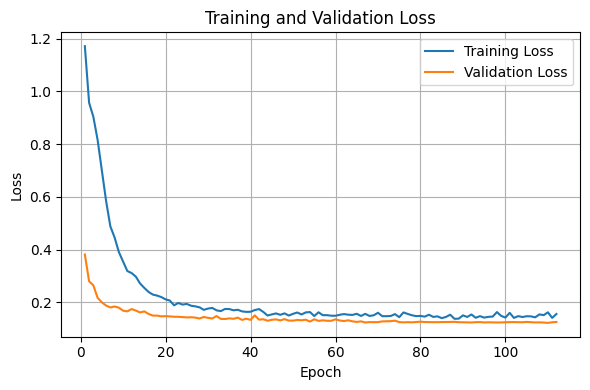

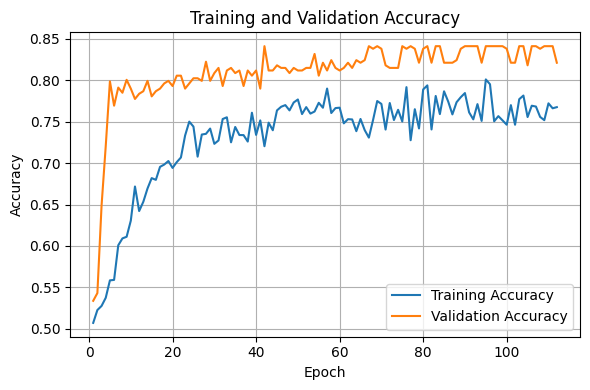

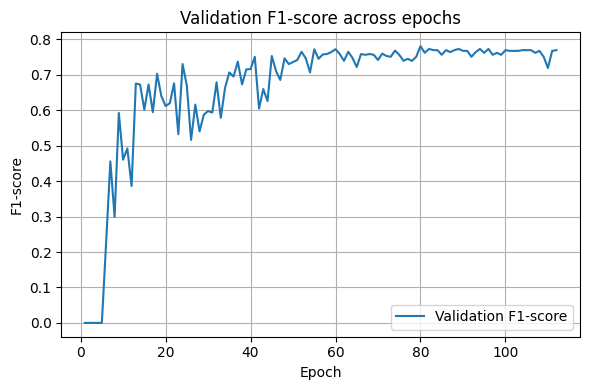

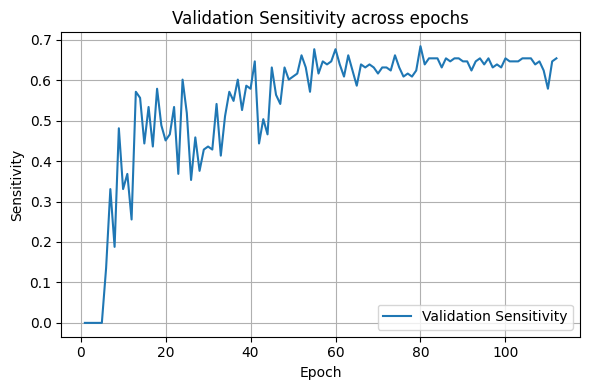

In [89]:

if __name__ == "__main__":
    # Train model với config hiện tại
    main(current_config)

    # Sau khi train xong, tự động test trên tập validation riêng (nếu có file)
    base_dir = Path(current_config['trainer']['save_dir']) / "models" / current_config['name']

# Test

In [1]:
from sklearn.metrics import f1_score, confusion_matrix, balanced_accuracy_score
from sklearn.metrics import accuracy_score
import numpy as np
import torch
from torch.utils.data import DataLoader
from pathlib import Path
import pandas as pd
def test_model(config, best_model_path, validation_fea_path, validation_label_csv, criterion=None):
    config_parser = ConfigParser(config)
    device, _ = prepare_device(config_parser['n_gpu'])

    # Khởi tạo model từ config (đảm bảo architecture đúng)
    model = config_parser.init_obj('arch', globals())
    model = model.to(device)

    # === LOAD CHỈ STATE_DICT - AN TOÀN, KHÔNG CẦN WHITELIST ===
    try:
        # Cách 1: Dùng weights_only=True (mặc định từ PT 2.6), chỉ load weights
        checkpoint = torch.load(best_model_path, map_location=device, weights_only=True)
        model.load_state_dict(checkpoint)  # checkpoint ở đây chỉ là state_dict
        print("Loaded model weights with weights_only=True (safe mode)")
    except Exception as e1:
        print(f"weights_only=True failed: {e1}")
        try:
            # Cách 2: Tắt weights_only (chỉ dùng nếu bạn tin tưởng file)
            checkpoint = torch.load(best_model_path, map_location=device, weights_only=False)
            if isinstance(checkpoint, dict) and 'state_dict' in checkpoint:
                model.load_state_dict(checkpoint['state_dict'])
                print("Loaded full checkpoint → state_dict")
            else:
                model.load_state_dict(checkpoint)
                print("Loaded raw state_dict")
        except Exception as e2:
            print(f"Cả hai cách đều thất bại: {e2}")
            return

    model.eval()

    print("\n=== MODEL ARCHITECTURE ===")
    print(model)
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"\nTrainable parameters: {trainable_params:,}")

    # === Xác định input shape từ config ===
    delta = config['data_loader']['args'].get('delta', False)
    n_mfcc = config['data_loader']['args'].get('n_mfcc', N_MFCC)
    actual_duration = config['data_loader']['args'].get('duration', 1.5)
    time_frames = TIME_FRAME

    channels = 3 if delta else 1   # static + Δ + ΔΔ nếu có
    height = n_mfcc

    # === Kiểm tra forward với input giả ===
    print("\n=== VERIFYING FORWARD PASS ===")
    try:
        with torch.no_grad():
            dummy_input = torch.randn(2, channels * height, time_frames).to(device)
            output = model(dummy_input)
            print(f"Input shape: (B, {channels * height}, {time_frames})")
            print(f"Output shape: {output.shape} → OK")
    except Exception as e:
        print(f"Forward pass error: {e}")

    # === Load validation data ===
    if not Path(validation_label_csv).exists() or not Path(validation_fea_path).exists():
        print("Validation files not found → skipping evaluation")
        return

    validation_label_df = pd.read_csv(validation_label_csv)
    validation_label_df['filename'] = validation_label_df['filename'].apply(lambda x: Path(x).stem)

    validation_dataset = HeartSoundDataSet(
        fea_path=validation_fea_path,
        labels=validation_label_df,
        duration=config['data_loader']['args']['duration'],
        training=False,
        delta=delta,
        norm=config['data_loader']['args'].get('norm', True)
    )

    print("\n=== DEBUG: SAMPLE FEATURES ===")
    for i in range(min(5, len(validation_dataset))):
        fea, lab = validation_dataset[i]
        print(f"Sample {i}: shape = {fea.shape}, label = {lab.item()}")

    # Tắt pin_memory trên CPU
    pin_memory = (device.type == 'cuda')

    validation_dataloader = DataLoader(
        validation_dataset,
        batch_size=config['data_loader']['args']['batch_size'],
        shuffle=False,
        num_workers=config['data_loader']['args'].get('num_workers', 2),
        pin_memory=pin_memory
    )

    if criterion is None:
        criterion = nn.CrossEntropyLoss()

    print("\n=== EVALUATING ON VALIDATION SET ===")
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total_samples = 0
    val_TP = val_TN = val_pred_pos = val_condition_pos = 0

    all_preds = []
    all_probs = []
    all_targets = []

    with torch.no_grad():
        for data, target in validation_dataloader:
            data, target = data.to(device).float(), target.to(device)
            output = model(data)
            loss = criterion(output, target)

            total_loss += loss.item() * data.size(0)
            _, pred = torch.max(output, 1)

            total_correct += (pred == target).sum().item()
            total_samples += target.size(0)

            pred_pos_idx = (pred == 1)      # class 1 = abnormal (positive)
            condition_pos_idx = (target == 1)

            val_TP += (pred_pos_idx & condition_pos_idx).sum().item()
            val_TN += ((pred == 0) & (target == 0)).sum().item()
            val_pred_pos += pred_pos_idx.sum().item()
            val_condition_pos += condition_pos_idx.sum().item()

            all_probs   = np.array(all_probs)
            all_preds.extend(pred.cpu().numpy())
            all_targets.extend(target.cpu().numpy())

    avg_loss = total_loss / total_samples
    accuracy = total_correct / total_samples
    sensitivity = val_TP / val_condition_pos if val_condition_pos > 0 else 0
    specificity = val_TN / (total_samples - val_condition_pos) if (total_samples - val_condition_pos) > 0 else 0
    MAcc = (sensitivity + specificity) / 2
    precision = val_TP / val_pred_pos if val_pred_pos > 0 else 0
    F1_score = 2 * precision * sensitivity / (precision + sensitivity) if (precision + sensitivity) > 0 else 0
    cm = confusion_matrix(all_targets, all_preds)
    val_log = {
        'loss': avg_loss,
        'accuracy': accuracy,
        'sensitivity': sensitivity,
        'specificity': specificity,
        'MAcc': MAcc,
        'F1_score': F1_score
    }

    print(f"\nDetailed Results:")
    for k, v in val_log.items():
        print(f"    {k}: {v:.4f}")


    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Normal (0)', 'Abnormal (1)'],
                yticklabels=['Normal (0)', 'Abnormal (1)'])
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title('Confusion Matrix - Heart Sound Classification')

    # Save image to the same directory as the model
    save_path = Path(best_model_path).parent / "confusion_matrix.png"
    plt.savefig(save_path, dpi=300)
    plt.show()
    print(f"\nConfusion Matrix has been saved at: {save_path}")

    # Print detailed classification report
    print("\nClassification Report:")
    print(classification_report(all_targets, all_preds, target_names=['Normal', 'Abnormal']))


    metrics_path = Path(best_model_path).parent / "test_on_validation_set_metrics.csv"
    pd.DataFrame([val_log]).to_csv(metrics_path, index=False)
    print(f"\nĐã lưu kết quả tại: {metrics_path}")


In [ ]:
'''
def test_model(config, best_model_path, validation_fea_path, validation_label_csv, criterion=None):
    config_parser = ConfigParser(config)
    device, _ = prepare_device(config_parser['n_gpu'])

    # 1. Khởi tạo và Load Model
    model = config_parser.init_obj('arch', globals())
    model = model.to(device)

    try:
        checkpoint = torch.load(best_model_path, map_location=device, weights_only=True)
        model.load_state_dict(checkpoint)
        print("Loaded model weights (safe mode)")
    except Exception:
        checkpoint = torch.load(best_model_path, map_location=device, weights_only=False)
        if isinstance(checkpoint, dict) and 'state_dict' in checkpoint:
            model.load_state_dict(checkpoint['state_dict'])
        else:
            model.load_state_dict(checkpoint)
        print("Loaded full checkpoint")

    model.eval()

    # 2. Chuẩn bị Dữ liệu
    if not Path(validation_label_csv).exists() or not Path(validation_fea_path).exists():
        print("Validation files not found → skipping")
        return

    validation_label_df = pd.read_csv(validation_label_csv)
    validation_label_df['filename'] = validation_label_df['filename'].apply(lambda x: Path(x).stem)

    validation_dataset = HeartSoundDataSet(
        fea_path=validation_fea_path,
        labels=validation_label_df,
        duration=config['data_loader']['args']['duration'],
        training=False,
        delta=config['data_loader']['args'].get('delta', False),
        norm=config['data_loader']['args'].get('norm', True)
    )

    validation_dataloader = DataLoader(
        validation_dataset,
        batch_size=config['data_loader']['args']['batch_size'],
        shuffle=False,
        num_workers=config['data_loader']['args'].get('num_workers', 2)
    )

    # 3. Thu thập xác suất (Probs) và nhãn thực (Targets)
    all_probs = []
    all_targets = []

    print("\n=== RUNNING INFERENCE ===")
    with torch.no_grad():
        for data, target in validation_dataloader:
            data, target = data.to(device).float(), target.to(device)
            output = model(data)

            # Chuyển Logits thành xác suất bằng Softmax
            probs = torch.softmax(output, dim=1)
            # Lưu xác suất của lớp Abnormal (Lớp 1)
            all_probs.extend(probs[:, 1].cpu().numpy())
            all_targets.extend(target.cpu().numpy())

    all_probs = np.array(all_probs)
    all_targets = np.array(all_targets)

    # 4. THRESHOLD TUNING: Tìm ngưỡng tối ưu
    thresholds = np.arange(0.1, 1.0, 0.05)
    tuning_results = []

    print(f"\n{'Threshold':<10} | {'Sens':<10} | {'Spec':<10} | {'MAcc':<10} | {'F1':<10}")
    print("-" * 65)

    for t in thresholds:
        preds = (all_probs >= t).astype(int)
        tn, fp, fn, tp = confusion_matrix(all_targets, preds).ravel()

        sens = tp / (tp + fn) if (tp + fn) > 0 else 0
        spec = tn / (tn + fp) if (tn + fp) > 0 else 0
        macc = (sens + spec) / 2
        f1 = f1_score(all_targets, preds)

        tuning_results.append({
            'threshold': t, 'sens': sens, 'spec': spec, 'macc': macc, 'f1': f1, 'cm': confusion_matrix(all_targets, preds)
        })
        print(f"{t:<10.2f} | {sens:<10.4f} | {spec:<10.4f} | {macc:<10.4f} | {f1:<10.4f}")

    # 5. Lấy ngưỡng tốt nhất theo MAcc
    best_res = max(tuning_results, key=lambda x: x['macc'])
    best_t = best_res['threshold']

    print(f"\n===> BEST THRESHOLD FOUND: {best_t:.2f}")
    print(f"Final MAcc: {best_res['macc']:.4f} (Sens: {best_res['sens']:.4f}, Spec: {best_res['spec']:.4f})")

    # 6. Vẽ Confusion Matrix cho ngưỡng tốt nhất
    plt.figure(figsize=(8, 6))
    sns.heatmap(best_res['cm'], annot=True, fmt='d', cmap='Blues',
                xticklabels=['Normal (0)', 'Abnormal (1)'],
                yticklabels=['Normal (0)', 'Abnormal (1)'])
    plt.xlabel(f'Predicted (Threshold={best_t:.2f})')
    plt.ylabel('True Label')
    plt.title(f'Confusion Matrix at Best MAcc Threshold')

    save_path = Path(best_model_path).parent / f"confusion_matrix_T{int(best_t*100)}.png"
    plt.savefig(save_path, dpi=300)
    plt.show()

    # 7. Lưu báo cáo
    report = classification_report(all_targets, (all_probs >= best_t).astype(int), target_names=['Normal', 'Abnormal'])
    print("\nClassification Report at Best Threshold:")
    print(report)

    # Lưu metrics vào CSV
    val_log = {
        'best_threshold': best_t,
        'accuracy': accuracy_score(all_targets, (all_probs >= best_t).astype(int)),
        'sensitivity': best_res['sens'],
        'specificity': best_res['spec'],
        'MAcc': best_res['macc'],
        'F1_score': best_res['f1']
    }
    metrics_path = Path(best_model_path).parent / "test_best_threshold_metrics.csv"
    pd.DataFrame([val_log]).to_csv(metrics_path, index=False)
    print(f"\nKết quả tối ưu đã lưu tại: {metrics_path}")
    '''

In [2]:
val_df = pd.read_csv(str(DATASET_PATH / 'label_validation.csv'))
print("\n=== PHÂN PHỐI LABEL (test/val set) ===")
print(val_df['label'].value_counts())
print(f"Tỷ lệ Abnormal: {val_df['label'].mean():.2%}")

NameError: name 'DATASET_PATH' is not defined

Loaded full checkpoint

=== RUNNING INFERENCE ===

Threshold  | Sens       | Spec       | MAcc       | F1        
-----------------------------------------------------------------
0.10       | 1.0000     | 0.2867     | 0.6433     | 0.7384    
0.15       | 1.0000     | 0.3133     | 0.6567     | 0.7457    
0.20       | 1.0000     | 0.3200     | 0.6600     | 0.7475    
0.25       | 1.0000     | 0.3333     | 0.6667     | 0.7512    
0.30       | 1.0000     | 0.3600     | 0.6800     | 0.7588    
0.35       | 1.0000     | 0.3733     | 0.6867     | 0.7626    
0.40       | 1.0000     | 0.3933     | 0.6967     | 0.7684    
0.45       | 1.0000     | 0.4133     | 0.7067     | 0.7744    
0.50       | 0.9801     | 0.4467     | 0.7134     | 0.7749    
0.55       | 0.9603     | 0.4867     | 0.7235     | 0.7775    
0.60       | 0.8146     | 0.6533     | 0.7340     | 0.7546    
0.65       | 0.6954     | 0.7800     | 0.7377     | 0.7266    
0.70       | 0.5629     | 0.8867     | 0.7248     | 0.6719    
0

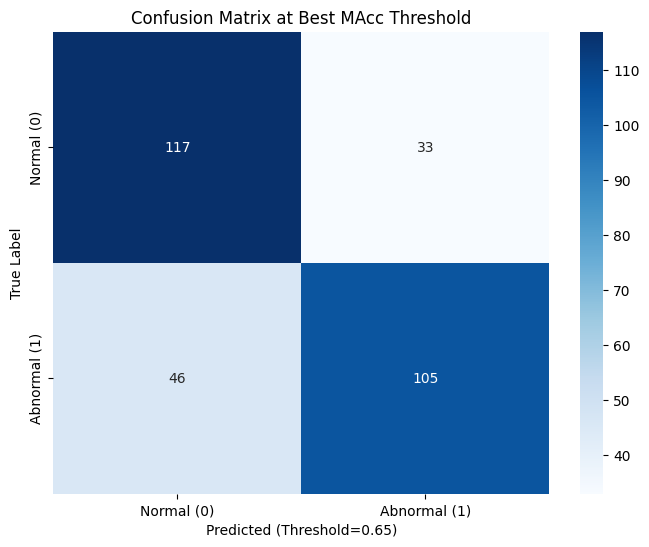


Classification Report at Best Threshold:
              precision    recall  f1-score   support

      Normal       0.72      0.78      0.75       150
    Abnormal       0.76      0.70      0.73       151

    accuracy                           0.74       301
   macro avg       0.74      0.74      0.74       301
weighted avg       0.74      0.74      0.74       301


Kết quả tối ưu đã lưu tại: /content/drive/MyDrive/AutomaticHeartSoundClassification-main/saved/lightweight_cnn/models/Physionet_lightweight_cnn/0325_154156/test_best_threshold_metrics.csv
Model size: 0.34 MB


In [92]:
base_dir = Path(current_config['trainer']['save_dir']) / "models" / current_config['name']
if base_dir.exists():
        latest_run = max(base_dir.iterdir(), key=os.path.getmtime)
        best_model_path = latest_run / "model_best.pth"

        validation_fea_path = str(DATASET_PATH / "mfcc_features_validation.h5")
        validation_label_csv = str(DATASET_PATH / "label_validation.csv")  # Đảm bảo file này tồn tại!

        if Path(validation_fea_path).exists() and Path(validation_label_csv).exists():
            test_model(
                current_config,
                best_model_path,
                validation_fea_path,
                validation_label_csv,
                criterion=AsymmetricFocalLoss(gamma_pos=1.0, gamma_neg=2.0, label_smoothing=0.1)
            )
        else:
            print("Không tìm thấy file validation .h5 hoặc label_validation.csv → Bỏ qua phần test.")

        size_bytes = os.path.getsize(best_model_path)
        size_mb = size_bytes / (1024 * 1024)

        print(f"Model size: {size_mb:.2f} MB")

else:
    print("Không tìm thấy thư mục saved models.")
